In [1]:
import cv2
import torch
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from random import randint, choices

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {DEVICE}")

Using device: cuda


# EDA CCD

## Contents:

### Load labels

In [2]:
labels_path = r"D:\MAGISTERKA\anomaly_traffic_road\datasets\CarCrash\labels.txt"

with open(labels_path, 'r') as f:
    labels = list(map(lambda x: x.strip().split(','), f.readlines()))

vid_name = [label[0] for label in labels]
vid_labels = [label[1:51] for label in labels]
vid_labels = [[int(num.replace('[', '').replace(']', '')) for num in label_list] for label_list in vid_labels]
day_or_night = [label[-3] for label in labels]
weather = [label[-2] for label in labels]
self_ego = [label[-1] for label in labels]

vid_labels = np.array(vid_labels)
day_or_night = np.array(day_or_night)
weather = np.array(weather)
self_ego = np.array(self_ego)

In [21]:
len(vid_labels)

1500

### Class distribution

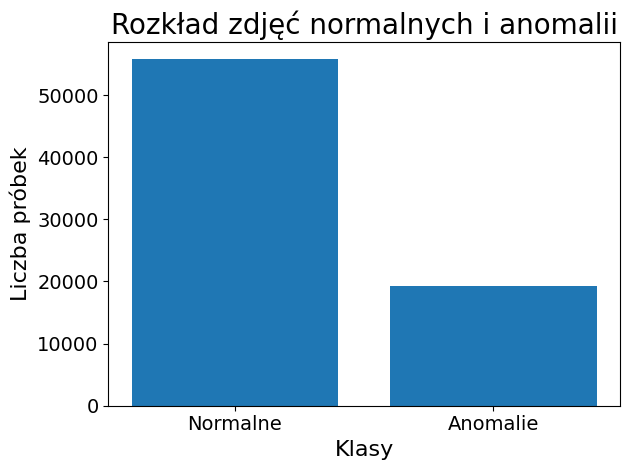

In [22]:
normal = 0
anomaly = 0

for l in vid_labels:
    normal += np.where(l == 0)[0].shape[0]
    anomaly += np.where(l == 1)[0].shape[0]

plt.bar(['Normalne', 'Anomalie'], [normal, anomaly])
plt.title('Rozkład zdjęć normalnych i anomalii', fontsize=20)
plt.xlabel('Klasy', fontsize=16)
plt.ylabel('Liczba próbek', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()

### Night distribution

Unique values: ['Day' 'Night']


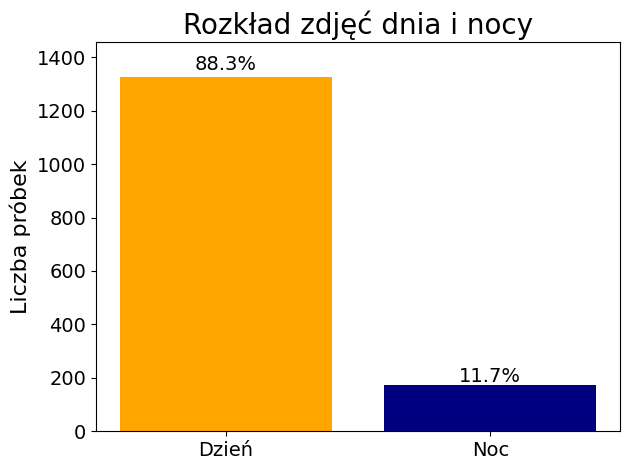

In [23]:
print(f"Unique values: {np.unique(day_or_night)}")
day_or_night = np.where(day_or_night == 'Day', 0, 1)

# Count occurrences
day_count = np.where(day_or_night == 0)[0].shape[0]
night_count = np.where(day_or_night == 1)[0].shape[0]
total = day_count + night_count

# Calculate percentages
day_percentage = (day_count / total) * 100
night_percentage = (night_count / total) * 100

plt.bar(['Dzień', 'Noc'], [np.where(day_or_night == 0)[0].shape[0], np.where(day_or_night == 1)[0].shape[0]], color=['#FFA500', '#000080'])

plt.text(0, day_count * 1.02, f'{day_percentage:.1f}%', ha='center', fontsize=14)
plt.text(1, night_count * 1.05, f'{night_percentage:.1f}%', ha='center', fontsize=14)

plt.title('Rozkład zdjęć dnia i nocy', fontsize=20)
plt.ylabel('Liczba próbek', fontsize=16)
plt.ylim(0, max(day_count, night_count) * 1.1)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()

### Weather distribution

Unique values: ['Normal' 'Rainy' 'Snowy']
[0 0 0 ... 2 2 0]


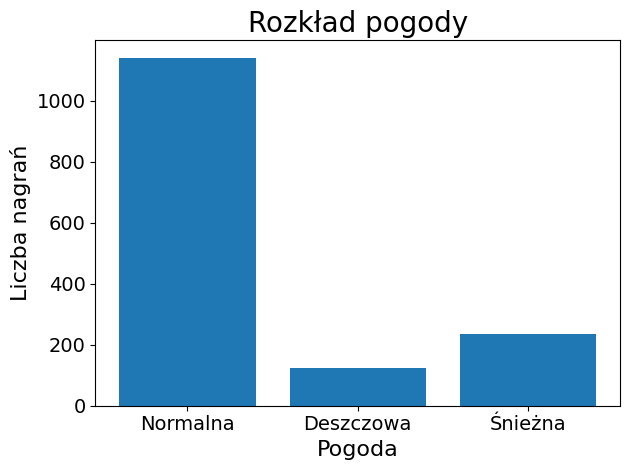

In [24]:
unique_values, labels = np.unique(weather, return_inverse=True)
print(f"Unique values: {unique_values}")
print(labels)

plt.bar(["Normalna", "Deszczowa", "Śnieżna"], [np.where(labels == i)[0].shape[0] for i in range(len(unique_values))])
plt.title('Rozkład pogody', fontsize=20)
plt.xlabel('Pogoda', fontsize=16)
plt.ylabel('Liczba nagrań', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()

### Ego involved

Text(0.5, 1.0, 'Czy nagrywający brał udział w wypadku')

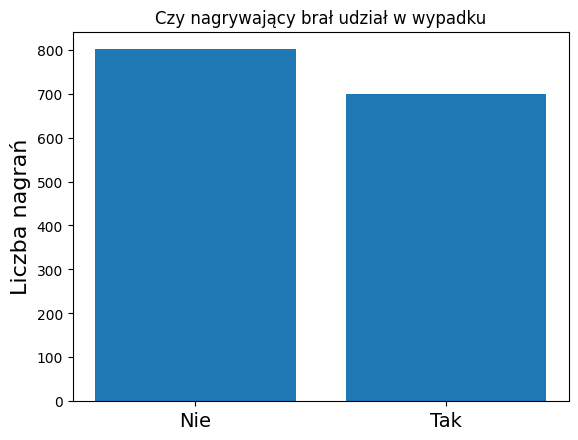

In [25]:
np.unique(self_ego)
self_ego = np.where(self_ego == 'Yes', 1, 0)

plt.bar(['Nie', 'Tak'], [len(np.where(self_ego == 1)[0]), len(np.where(self_ego == 0)[0])])
plt.xticks(fontsize=14)
plt.ylabel("Liczba nagrań", fontsize=16)
plt.title("Czy nagrywający brał udział w wypadku")

### Load images paths

In [4]:
sets = ['train', 'val']
images_paths = [[], []] # 1st index train, 2nd - val
dataset_path = Path(r"D:\MAGISTERKA\anomaly_traffic_road\datasets\CarCrash\frames")

for i, s in enumerate(sets):
    p = dataset_path / s
    videos_paths = p.glob('*')

    for video_path in videos_paths:
        essa = list(video_path.glob('*.jpg'))
        if len(essa) != 50:
            print(f"{video_path} has less than 50 frames: {len(essa)}")
        images_paths[i].append(essa)

print(f"# of frames in train set: {len(images_paths[0])}")
print(f"# of frames in val set: {len(images_paths[1])}")


D:\MAGISTERKA\anomaly_traffic_road\datasets\CarCrash\frames\train\000615 has less than 50 frames: 49
D:\MAGISTERKA\anomaly_traffic_road\datasets\CarCrash\frames\train\002058 has less than 50 frames: 49
# of frames in train set: 3000
# of frames in val set: 1500


### Show few normals and few anomalies

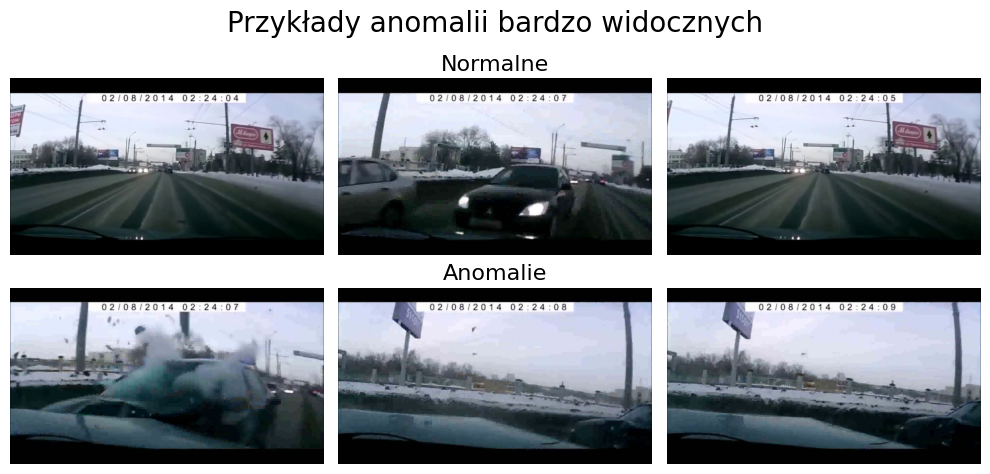

In [27]:
idx = randint(0, len(vid_labels))
titles = ["Normalne", "Anomalie"]

video = images_paths[1][idx]
targets = vid_labels[idx]

fig, axs = plt.subplots(2, 3, figsize=(10, 5))

for i in range(2):
    indices = choices(np.where(targets == i)[0], k=3)
    for j, idx in enumerate(indices):
        image = cv2.cvtColor(cv2.imread(video[idx]), cv2.COLOR_BGR2RGB)
        axs[i, j].imshow(image)
        axs[i, j].axis('off')
        if j == 1:
            axs[i, j].set_title(titles[i], fontsize=16)

fig.suptitle("Przykłady anomalii bardzo widocznych", fontsize=20)
plt.tight_layout()

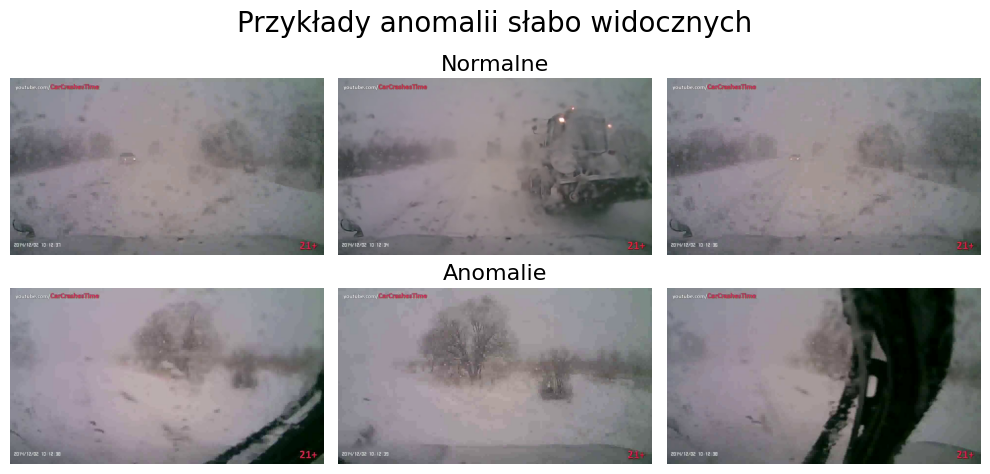

In [28]:
idx = randint(0, len(vid_labels))
titles = ["Normalne", "Anomalie"]

video = images_paths[1][idx]
targets = vid_labels[idx]

fig, axs = plt.subplots(2, 3, figsize=(10, 5))

for i in range(2):
    indices = choices(np.where(targets == i)[0], k=3)
    for j, idx in enumerate(indices):
        image = cv2.cvtColor(cv2.imread(video[idx]), cv2.COLOR_BGR2RGB)
        axs[i, j].imshow(image)
        axs[i, j].axis('off')
        if j == 1:
            axs[i, j].set_title(titles[i], fontsize=16)

fig.suptitle("Przykłady anomalii słabo widocznych", fontsize=20)
plt.tight_layout()

### Colors

<a href="back">Go back</a>

  0%|          | 0/2790 [00:00<?, ?it/s]

  0%|          | 0/2790 [00:00<?, ?it/s]

  0%|          | 0/2790 [00:00<?, ?it/s]

  0%|          | 0/2790 [00:00<?, ?it/s]

  0%|          | 0/2789 [00:00<?, ?it/s]

...

  0%|          | 0/961 [00:00<?, ?it/s]

  0%|          | 0/961 [00:00<?, ?it/s]

  0%|          | 0/961 [00:00<?, ?it/s]

  0%|          | 0/961 [00:00<?, ?it/s]

  0%|          | 0/960 [00:00<?, ?it/s]

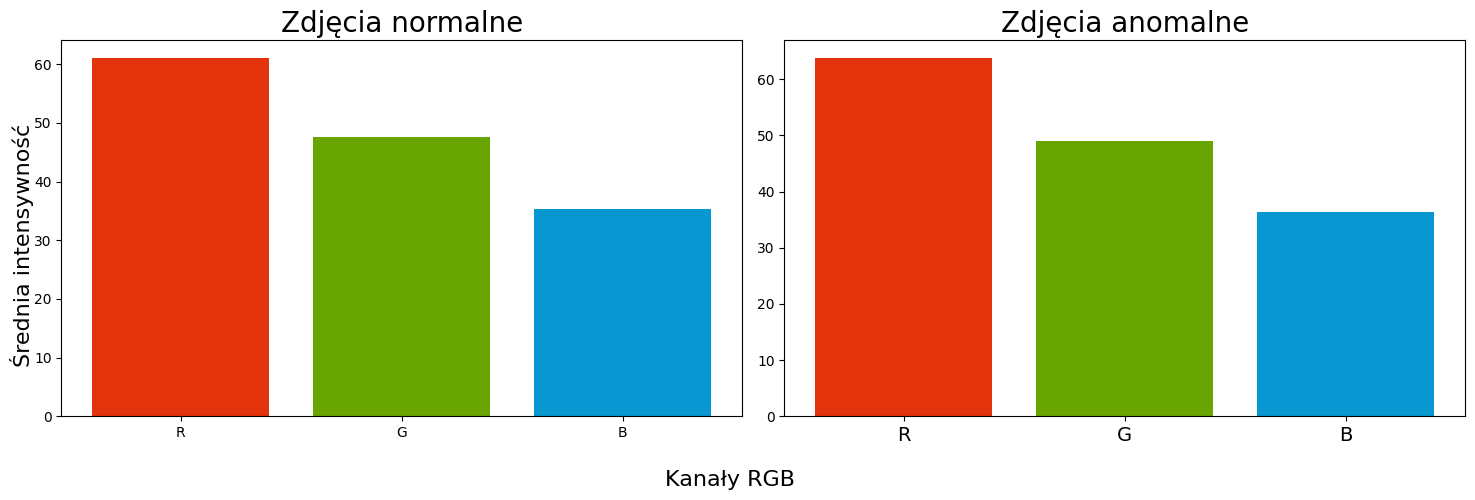

In [36]:
import torch
import numpy as np
from tqdm.notebook import tqdm
from concurrent.futures import ThreadPoolExecutor
import os
import matplotlib.pyplot as plt
import seaborn as sns

normal_indices = torch.where(torch.tensor(vid_labels) == 0)[0]
anomaly_indices = torch.where(torch.tensor(vid_labels) != 0)[0]

imgs = []
for i in range(len(images_paths[0])):
    for j in range(len(images_paths[0][i])):
        imgs.append(images_paths[0][i][j])

w, h = cv2.imread(str(imgs[0])).shape[:2]

def calculate_mean(indices, dataset, desc=None):
    mean = torch.zeros(3, w, h)
    for i in tqdm(indices, desc=desc, leave=False):
        img = cv2.cvtColor(cv2.imread(str(imgs[i])), cv2.COLOR_BGR2RGB).reshape(3, w, h)
        mean += img
    return mean

# Podziel indeksy na mniejsze partie
def split_indices(indices, n_chunks=os.cpu_count()):
    return np.array_split(indices, n_chunks)

# Zrównoleglone obliczenia
with ThreadPoolExecutor(max_workers=os.cpu_count()) as executor:
    # Podziel indeksy na partie
    normal_chunks = split_indices(normal_indices)
    anomaly_chunks = split_indices(anomaly_indices)
    
    # Oblicz średnie dla każdej partii
    normal_means = list(executor.map(lambda chunk: calculate_mean(chunk, []), normal_chunks))
    anomaly_means = list(executor.map(lambda chunk: calculate_mean(chunk, images_paths[1]), anomaly_chunks))

# Zsumuj wyniki
mean_normal = sum(normal_means) / len(normal_indices)
mean_anomaly = sum(anomaly_means) / len(anomaly_indices)

mean_normal_r = mean_normal[0].mean()
mean_normal_g = mean_normal[1].mean()
mean_normal_b = mean_normal[2].mean()

mean_anomaly_r = mean_anomaly[0].mean()
mean_anomaly_g = mean_anomaly[1].mean()
mean_anomaly_b = mean_anomaly[2].mean()

# Ustawienie palety kolorów
sns.set_palette("husl")

# Kolory HEX dla lepszego wyglądu
colors_normal = ["#e3330d", "#69a501", "#0997d1"]
colors_anomaly = ["#e3330d", "#69a501", "#0997d1"]

# Tworzenie wykresów z nowymi kolorami
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
axs[0].bar(range(3), [mean_normal_r, mean_normal_g, mean_normal_b], color=colors_normal)
axs[0].set_title("Zdjęcia normalne", fontsize=20)
axs[0].set_xticks(range(3), ["R", "G", "B"])

axs[1].bar(range(3), [mean_anomaly_r, mean_anomaly_g, mean_anomaly_b], color=colors_anomaly)
axs[1].set_title("Zdjęcia anomalne", fontsize=20)
axs[1].set_xticks(range(3), ["R", "G", "B"], fontsize=14)

fig.supxlabel("Kanały RGB", fontsize=16)
fig.supylabel("Średnia intensywność", fontsize=16)

plt.tight_layout()
plt.show()

### Histogram RGB

  0%|          | 0/2790 [00:00<?, ?it/s]

  0%|          | 0/2790 [00:00<?, ?it/s]

  0%|          | 0/2789 [00:00<?, ?it/s]

  0%|          | 0/2789 [00:00<?, ?it/s]

  0%|          | 0/2789 [00:00<?, ?it/s]

...

  0%|          | 0/961 [00:00<?, ?it/s]

  0%|          | 0/961 [00:00<?, ?it/s]

  0%|          | 0/960 [00:00<?, ?it/s]

  0%|          | 0/961 [00:00<?, ?it/s]

  0%|          | 0/961 [00:00<?, ?it/s]

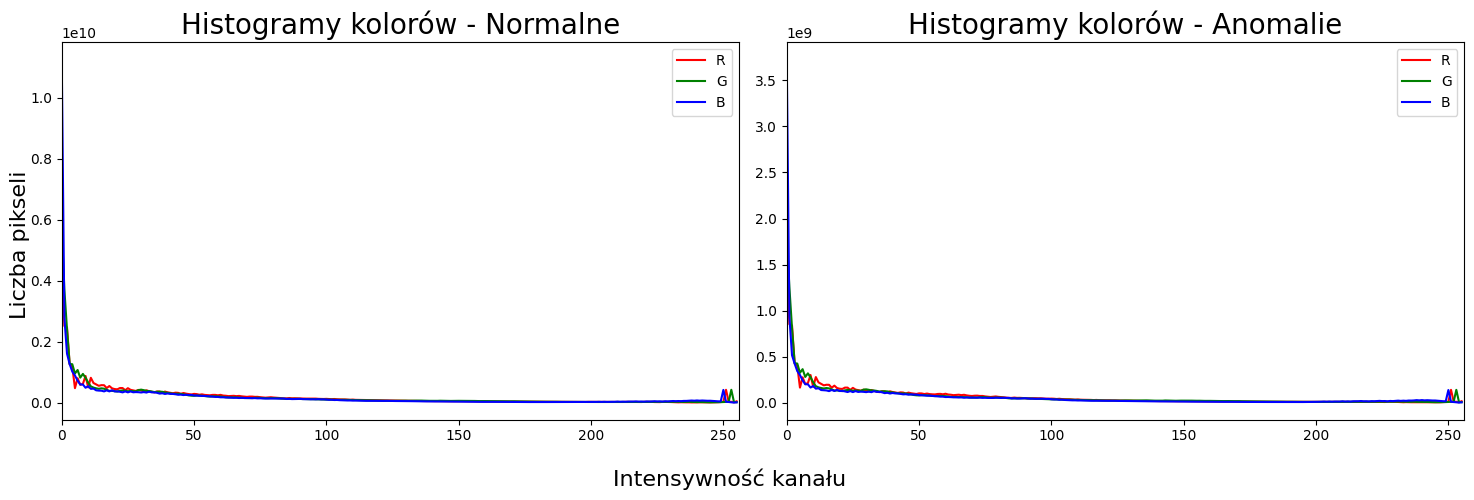

In [40]:
from concurrent.futures import ThreadPoolExecutor
import os
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import numpy as np
from tqdm.notebook import tqdm

normal_indices = torch.where(torch.tensor(vid_labels) == 0)[0]
anomaly_indices = torch.where(torch.tensor(vid_labels) != 0)[0]

imgs = []
for i in range(len(images_paths[0])):
    for j in range(len(images_paths[0][i])):
        imgs.append(images_paths[0][i][j])


def calculate_histograms(indices, dataset, desc=None):
    hist_r = torch.zeros(256)
    hist_g = torch.zeros(256)
    hist_b = torch.zeros(256)
    for i in tqdm(indices, desc=desc, leave=False):
        image_np = cv2.imread(str(dataset[i]))
        
        if image_np is None:
            print(f"Warning: Could not read image at path: {dataset[i]}")
            continue

        image_rgb = cv2.cvtColor(image_np, cv2.COLOR_BGR2RGB)
        img = torch.from_numpy(image_rgb).float() 
        img = img.permute(2, 0, 1)

        hist_r += torch.histc(img[0], bins=256, min=0, max=255)
        hist_g += torch.histc(img[1], bins=256, min=0, max=255)
        hist_b += torch.histc(img[2], bins=256, min=0, max=255)
        
    return hist_r, hist_g, hist_b

# Podziel indeksy na mniejsze partie
def split_indices(indices, n_chunks=os.cpu_count()):
    return np.array_split(indices, n_chunks)

# Zrównoleglone obliczenia
with ThreadPoolExecutor(max_workers=os.cpu_count()) as executor:
    # Podziel indeksy na partie
    normal_chunks = split_indices(normal_indices)
    anomaly_chunks = split_indices(anomaly_indices)
    
    # Oblicz średnie dla każdej partii
    normal_results = list(executor.map(lambda chunk: calculate_histograms(chunk, imgs), normal_chunks))
    anomaly_results = list(executor.map(lambda chunk: calculate_histograms(chunk, imgs), anomaly_chunks))

normal_hist_r = torch.zeros(256)
normal_hist_g = torch.zeros(256)
normal_hist_b = torch.zeros(256)

anomaly_hist_r = torch.zeros(256)
anomaly_hist_g = torch.zeros(256)
anomaly_hist_b = torch.zeros(256)

for r, g, b in normal_results:
    normal_hist_r += r
    normal_hist_g += g
    normal_hist_b += b

for r, g, b in anomaly_results:
    anomaly_hist_r += r
    anomaly_hist_g += g
    anomaly_hist_b += b

# Wizualizacja histogramów
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

# Wykres dla obrazów normalnych
axs[0].plot(range(256), normal_hist_r.numpy(), color='red', label='R')
axs[0].plot(range(256), normal_hist_g.numpy(), color='green', label='G')
axs[0].plot(range(256), normal_hist_b.numpy(), color='blue', label='B')
axs[0].set_title('Histogramy kolorów - Normalne', fontsize=20)
axs[0].set_xlim([0, 256])
axs[0].legend()

# Wykres dla anomalii
axs[1].plot(range(256), anomaly_hist_r.numpy(), color='red', label='R')
axs[1].plot(range(256), anomaly_hist_g.numpy(), color='green', label='G')
axs[1].plot(range(256), anomaly_hist_b.numpy(), color='blue', label='B')
axs[1].set_title('Histogramy kolorów - Anomalie', fontsize=20)
axs[1].set_xlim([0, 256])
axs[1].legend()

fig.supxlabel("Intensywność kanału", fontsize=16)
fig.supylabel("Liczba pikseli", fontsize=16)

plt.tight_layout()
plt.show()

### Histogram grayscale

  0%|          | 0/2790 [00:00<?, ?it/s]

  0%|          | 0/2790 [00:00<?, ?it/s]

  0%|          | 0/2789 [00:00<?, ?it/s]

  0%|          | 0/2789 [00:00<?, ?it/s]

  0%|          | 0/2789 [00:00<?, ?it/s]

...

  0%|          | 0/961 [00:00<?, ?it/s]

  0%|          | 0/960 [00:00<?, ?it/s]

  0%|          | 0/961 [00:00<?, ?it/s]

  0%|          | 0/961 [00:00<?, ?it/s]

  0%|          | 0/960 [00:00<?, ?it/s]

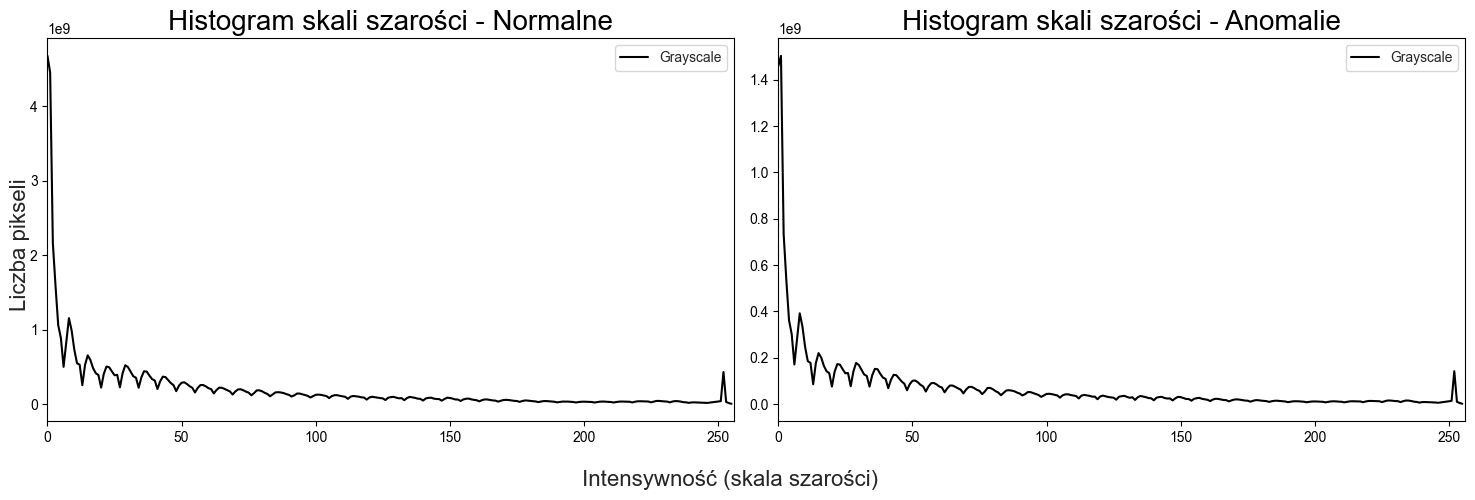

In [5]:
from concurrent.futures import ThreadPoolExecutor
import os
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import numpy as np
from tqdm.notebook import tqdm
import cv2 # Dodano import biblioteki OpenCV

# --- Zakładamy, że te zmienne są zdefiniowane wcześniej ---
# Przykład:
# vid_labels = [0, 0, 1, 0, 1, ...] # Lista etykiet dla każdego wideo
# images_paths = [[['path/to/img1.jpg', 'path/to/img2.jpg'], ['path/to/img3.jpg', ...]], ...] # Zagnieżdżona lista ścieżek
# -----------------------------------------------------------

normal_indices = torch.where(torch.tensor(vid_labels) == 0)[0]
anomaly_indices = torch.where(torch.tensor(vid_labels) != 0)[0]

# Ta część pozostaje bez zmian
imgs = []
for i in range(len(images_paths[0])):
    for j in range(len(images_paths[0][i])):
        imgs.append(images_paths[0][i][j])

def calculate_grayscale_histograms(indices, dataset, desc=None):
    """
    Oblicza zagregowany histogram dla obrazów w skali szarości.
    """
    hist_gray = torch.zeros(256)
    for i in tqdm(indices, desc=desc, leave=False):
        image_np = cv2.imread(str(dataset[i]))
        
        if image_np is None:
            print(f"Warning: Could not read image at path: {dataset[i]}")
            continue

        # Konwersja obrazu do skali szarości
        gray_np = cv2.cvtColor(image_np, cv2.COLOR_BGR2GRAY)
        
        # Konwersja do tensora PyTorch
        img_gray = torch.from_numpy(gray_np).float() 
        
        # Obliczenie histogramu dla pojedynczego kanału (skali szarości)
        hist_gray += torch.histc(img_gray, bins=256, min=0, max=255)
        
    return hist_gray

# Funkcja do podziału indeksów pozostaje bez zmian
def split_indices(indices, n_chunks=os.cpu_count()):
    return np.array_split(indices, n_chunks)

# Zrównoleglone obliczenia dla skali szarości
with ThreadPoolExecutor(max_workers=os.cpu_count()) as executor:
    # Podziel indeksy na partie
    normal_chunks = split_indices(normal_indices)
    anomaly_chunks = split_indices(anomaly_indices)
    
    # Oblicz histogramy dla każdej partii (używając nowej funkcji)
    normal_results = list(executor.map(lambda chunk: calculate_grayscale_histograms(chunk, imgs), normal_chunks))
    anomaly_results = list(executor.map(lambda chunk: calculate_grayscale_histograms(chunk, imgs), anomaly_chunks))

# Agregacja wyników
normal_hist_gray = torch.zeros(256)
anomaly_hist_gray = torch.zeros(256)

for hist in normal_results:
    normal_hist_gray += hist

for hist in anomaly_results:
    anomaly_hist_gray += hist

# Wizualizacja histogramów dla skali szarości
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
sns.set_style("whitegrid")

# Wykres dla obrazów normalnych
axs[0].plot(range(256), normal_hist_gray.numpy(), color='black', label='Grayscale')
axs[0].set_title('Histogram skali szarości - Normalne', fontsize=20)
axs[0].set_xlim([0, 256])
axs[0].legend()

# Wykres dla anomalii
axs[1].plot(range(256), anomaly_hist_gray.numpy(), color='black', label='Grayscale')
axs[1].set_title('Histogram skali szarości - Anomalie', fontsize=20)
axs[1].set_xlim([0, 256])
axs[1].legend()

fig.supxlabel("Intensywność (skala szarości)", fontsize=16)
fig.supylabel("Liczba pikseli", fontsize=16)

plt.tight_layout()
plt.show()

Krok 1: Wczytywanie ścieżek i etykiet...
Ostrzeżenie: 000615 ma 49 klatek zamiast 50.
Ostrzeżenie: 002058 ma 49 klatek zamiast 50.
Liczba wideo w zbiorze treningowym: 3000
Liczba wideo w zbiorze walidacyjnym: 1500
Wczytywanie danych zakończone.

Krok 2: Przygotowywanie danych do analizy...
Przetwarzanie 3000 filmów ze zbioru 'train' (wszystkie jako 'Normalne')...
Przetwarzanie 1500 filmów ze zbioru 'val' (używając etykiet z pliku)...

Łączna liczba sekwencji wideo do analizy: 4500

Krok 3: Rozpoczynanie analizy ostrości...


Analizowanie wideo:   0%|          | 0/4500 [00:00<?, ?it/s]


Krok 4: Zebrano dane dla 4500 wideo. Generowanie wykresu...


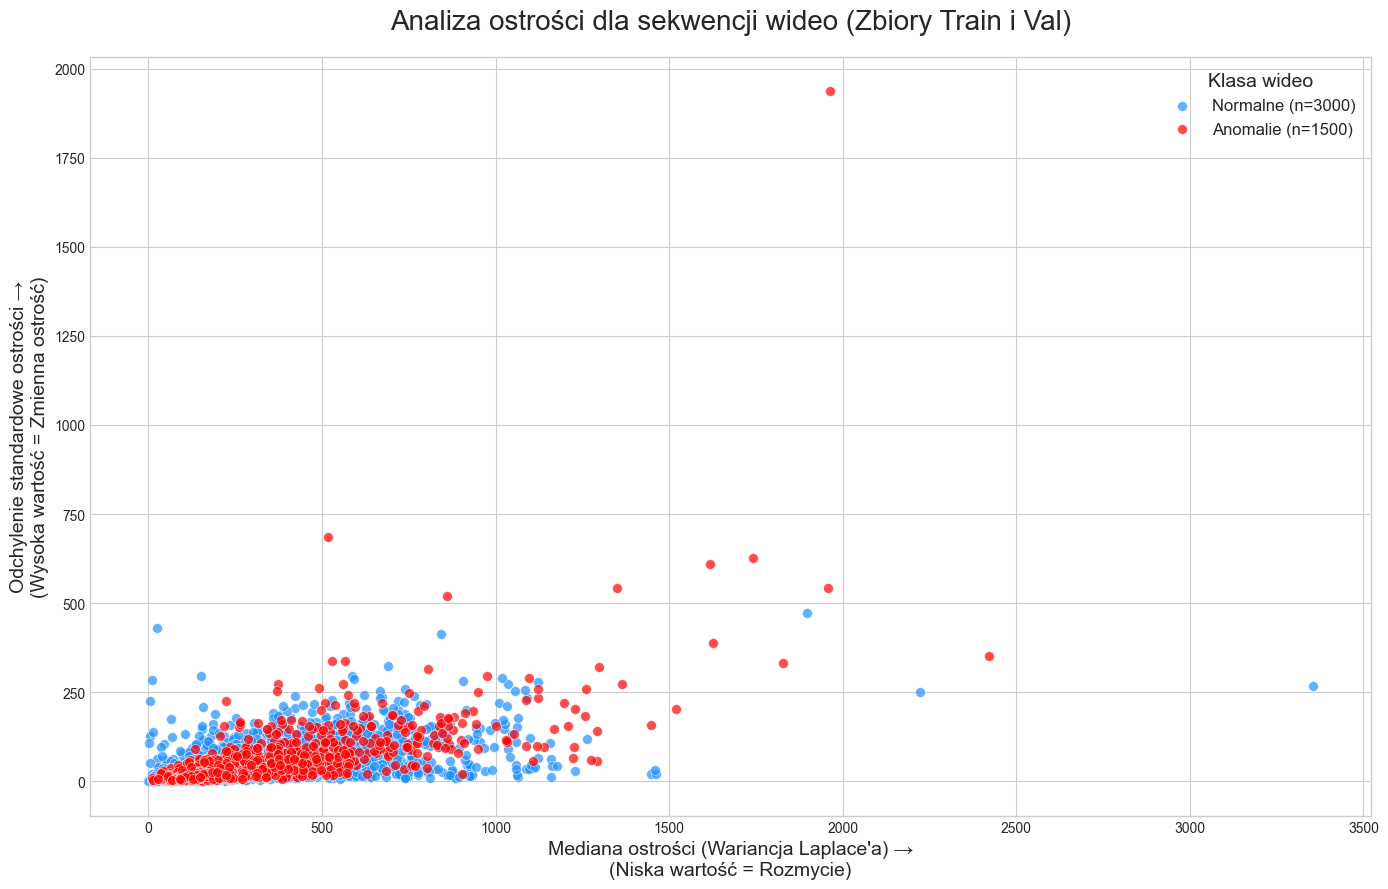

In [7]:
import cv2
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from concurrent.futures import ThreadPoolExecutor
import os

# ==============================================================================
# Krok 1: Wczytywanie danych (bez zmian)
# ==============================================================================
print("Krok 1: Wczytywanie ścieżek i etykiet...")

# --- Wczytywanie ścieżek do obrazów ---
sets = ['train', 'val']
images_paths = [[], []] # 0: train, 1: val
dataset_path = Path(r"D:\MAGISTERKA\anomaly_traffic_road\datasets\CarCrash\frames")

for i, s in enumerate(sets):
    p = dataset_path / s
    if not p.exists():
        print(f"Ostrzeżenie: Ścieżka dla zestawu '{s}' nie istnieje: {p}")
        continue
    videos_paths = sorted(list(p.glob('*')))

    for video_path in videos_paths:
        if not video_path.is_dir(): continue
        frame_list = sorted(list(video_path.glob('*.jpg')))
        if len(frame_list) != 50:
            print(f"Ostrzeżenie: {video_path.name} ma {len(frame_list)} klatek zamiast 50.")
        if frame_list:
            images_paths[i].append(frame_list)

print(f"Liczba wideo w zbiorze treningowym: {len(images_paths[0])}")
print(f"Liczba wideo w zbiorze walidacyjnym: {len(images_paths[1])}")

# --- Wczytywanie etykiet (dotyczą tylko zbioru 'val') ---
labels_path = r"D:\MAGISTERKA\anomaly_traffic_road\datasets\CarCrash\labels.txt"

with open(labels_path, 'r') as f:
    labels = list(map(lambda x: x.strip().split(','), f.readlines()))

vid_name = [label[0] for label in labels]
vid_labels_frames = [[int(num.replace('[', '').replace(']', '')) for num in label_list] for label_list in [label[1:51] for label in labels]]

print("Wczytywanie danych zakończone.")


# ==============================================================================
# Krok 2: Przygotowanie danych do analizy (NOWA LOGIKA)
# ==============================================================================
print("\nKrok 2: Przygotowywanie danych do analizy...")

# Stwórz słownik mapujący nazwę wideo na zagregowaną etykietę (tylko dla 'val')
label_dict = {}
for name, frame_labels in zip(vid_name, vid_labels_frames):
    video_label = max(frame_labels) # Agregacja: 1 jeśli jest jakakolwiek anomalia
    label_dict[name] = video_label

# Lista zadań do przetworzenia w wątkach: (lista_ścieżek, etykieta)
video_data_list = []

# --- Przetwarzanie zbioru TRENINGOWEGO ---
# Zakładamy, że wszystkie filmy w 'train' są normalne (etykieta 0)
print(f"Przetwarzanie {len(images_paths[0])} filmów ze zbioru 'train' (wszystkie jako 'Normalne')...")
for train_video_paths in images_paths[0]: # images_paths[0] to zbiór 'train'
    if train_video_paths:
        # Etykieta jest na stałe ustawiona na 0
        video_data_list.append((train_video_paths, 0))

# --- Przetwarzanie zbioru WALIDACYJNEGO ---
# Używamy etykiet z pliku do określenia klasy (0 lub 1)
print(f"Przetwarzanie {len(images_paths[1])} filmów ze zbioru 'val' (używając etykiet z pliku)...")
for val_video_paths in images_paths[1]: # images_paths[1] to zbiór 'val'
    if val_video_paths:
        # Nazwa wideo to nazwa katalogu nadrzędnego
        video_name_from_path = val_video_paths[0].parent.name
        
        # Znajdź etykietę dla tego wideo w słowniku
        if video_name_from_path in label_dict:
            video_label = label_dict[video_name_from_path]
            video_data_list.append((val_video_paths, video_label))
        else:
            print(f"Ostrzeżenie: Nie znaleziono etykiety dla wideo '{video_name_from_path}' ze zbioru 'val'. Pomijanie.")

print(f"\nŁączna liczba sekwencji wideo do analizy: {len(video_data_list)}")


# ==============================================================================
# Krok 3: Analiza ostrości (bez zmian)
# ==============================================================================
print("\nKrok 3: Rozpoczynanie analizy ostrości...")

def calculate_frame_sharpness(frame_bgr):
    if frame_bgr is None: return 0.0
    gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()

def process_video_sharpness(video_frame_paths, video_label):
    if not video_frame_paths: return None
    sharpness_scores = [calculate_frame_sharpness(cv2.imread(str(p))) for p in video_frame_paths]
    sharpness_scores = [s for s in sharpness_scores if s is not None]
    if sharpness_scores:
        return {'median_sharpness': np.median(sharpness_scores), 'std_dev_sharpness': np.std(sharpness_scores), 'label': video_label}
    return None

video_level_metrics = []
with ThreadPoolExecutor(max_workers=os.cpu_count()) as executor:
    results_iterator = executor.map(lambda data: process_video_sharpness(data[0], data[1]), video_data_list)
    for result in tqdm(results_iterator, total=len(video_data_list), desc="Analizowanie wideo"):
        if result is not None:
            video_level_metrics.append(result)


# ==============================================================================
# Krok 4: Wizualizacja wyników (bez zmian)
# ==============================================================================
if not video_level_metrics:
    print("Nie udało się zebrać danych do analizy ostrości.")
else:
    print(f"\nKrok 4: Zebrano dane dla {len(video_level_metrics)} wideo. Generowanie wykresu...")
    
    CLASS_NAMES = {0: 'Normalne', 1: 'Anomalie'}
    COLORS = {0: 'dodgerblue', 1: 'red'}

    median_list = [m['median_sharpness'] for m in video_level_metrics]
    std_dev_list = [m['std_dev_sharpness'] for m in video_level_metrics]
    labels_list = [m['label'] for m in video_level_metrics]

    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(14, 9))

    for label_id, class_name in CLASS_NAMES.items():
        class_mask = [l == label_id for l in labels_list]
        x = [b for b, m in zip(median_list, class_mask) if m]
        y = [s for s, m in zip(std_dev_list, class_mask) if m]
        
        if x:
            ax.scatter(x, y, color=COLORS[label_id], label=f"{class_name} (n={len(x)})", alpha=0.7, s=50, edgecolors='w', linewidth=0.5)

    ax.set_title('Analiza ostrości dla sekwencji wideo (Zbiory Train i Val)', fontsize=20, pad=20)
    ax.set_xlabel('Mediana ostrości (Wariancja Laplace\'a) →\n(Niska wartość = Rozmycie)', fontsize=14)
    ax.set_ylabel('Odchylenie standardowe ostrości →\n(Wysoka wartość = Zmienna ostrość)', fontsize=14)
    ax.legend(title='Klasa wideo', fontsize=12, title_fontsize=14)
    plt.tight_layout()
    plt.show()

### Optic flow

Krok 1: Wczytywanie ścieżek i etykiet...
Liczba wideo w zbiorze treningowym: 3000
Liczba wideo w zbiorze walidacyjnym: 1500
Wczytywanie danych zakończone.

Krok 2: Przygotowywanie danych do analizy...

Łączna liczba sekwencji wideo do analizy: 4500

Krok 3: Rozpoczynanie analizy przepływu optycznego...


Analizowanie ruchu:   0%|          | 0/4500 [00:00<?, ?it/s]


Krok 4: Zebrano dane dla 4500 wideo. Generowanie wykresu...


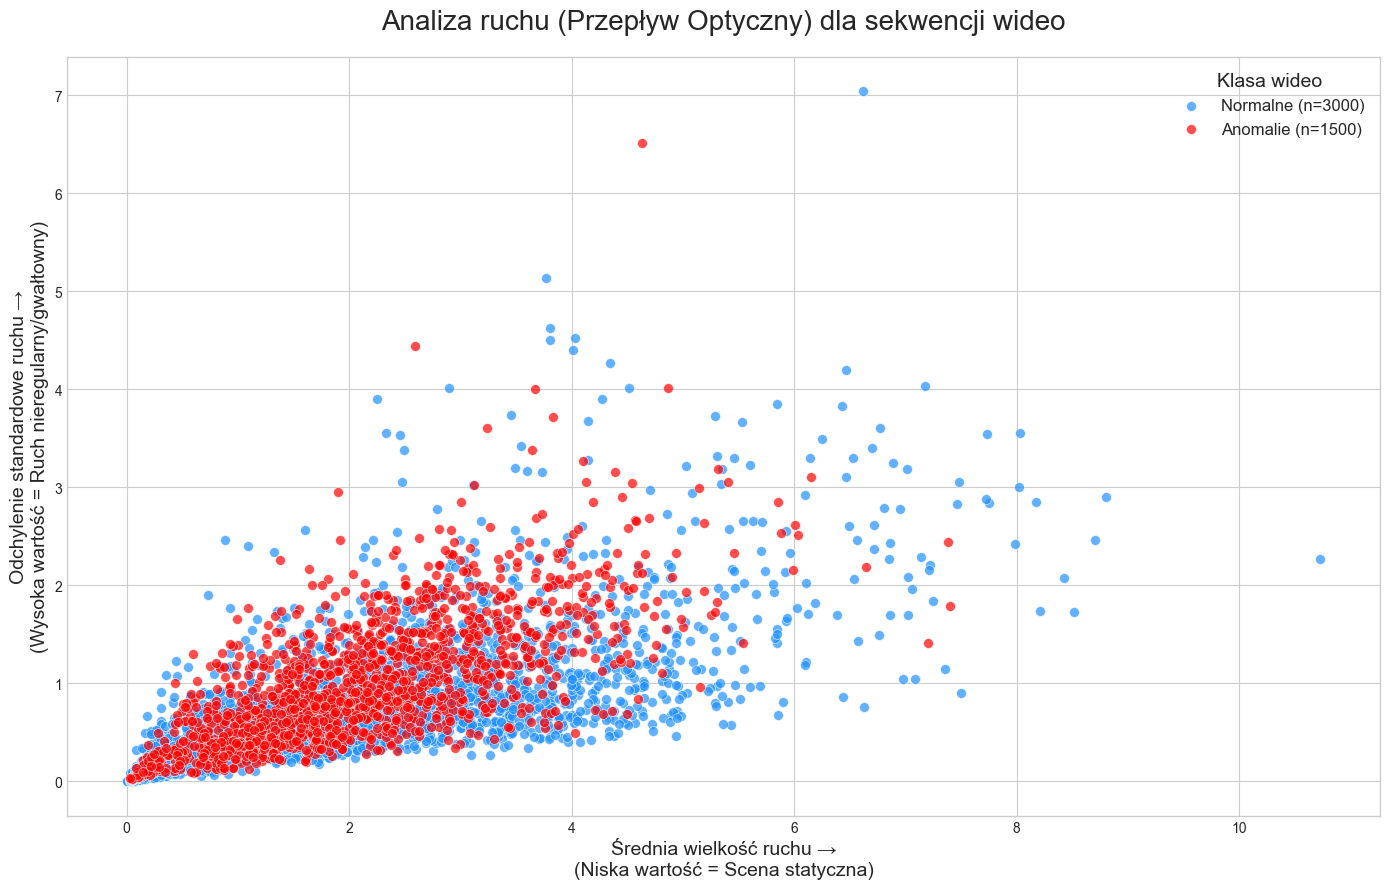

In [8]:
import cv2
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from concurrent.futures import ThreadPoolExecutor
import os

# ==============================================================================
# Krok 1: Wczytywanie danych (bez zmian, taka sama logika jak poprzednio)
# ==============================================================================
print("Krok 1: Wczytywanie ścieżek i etykiet...")

# --- Wczytywanie ścieżek do obrazów ---
sets = ['train', 'val']
images_paths = [[], []] # 0: train, 1: val
dataset_path = Path(r"D:\MAGISTERKA\anomaly_traffic_road\datasets\CarCrash\frames")

for i, s in enumerate(sets):
    p = dataset_path / s
    if not p.exists(): continue
    videos_paths = sorted(list(p.glob('*')))

    for video_path in videos_paths:
        if not video_path.is_dir(): continue
        frame_list = sorted(list(video_path.glob('*.jpg')))
        if frame_list: images_paths[i].append(frame_list)

print(f"Liczba wideo w zbiorze treningowym: {len(images_paths[0])}")
print(f"Liczba wideo w zbiorze walidacyjnym: {len(images_paths[1])}")

# --- Wczytywanie etykiet (dotyczą tylko zbioru 'val') ---
labels_path = r"D:\MAGISTERKA\anomaly_traffic_road\datasets\CarCrash\labels.txt"
with open(labels_path, 'r') as f:
    labels = list(map(lambda x: x.strip().split(','), f.readlines()))
vid_name = [label[0] for label in labels]
vid_labels_frames = [[int(num.replace('[', '').replace(']', '')) for num in label_list] for label_list in [label[1:51] for label in labels]]
print("Wczytywanie danych zakończone.")


# ==============================================================================
# Krok 2: Przygotowanie danych do analizy (bez zmian, taka sama logika jak poprzednio)
# ==============================================================================
print("\nKrok 2: Przygotowywanie danych do analizy...")

label_dict = {name: max(frame_labels) for name, frame_labels in zip(vid_name, vid_labels_frames)}
video_data_list = []

# Zbiór treningowy (wszystkie normalne)
for train_video_paths in images_paths[0]:
    if train_video_paths: video_data_list.append((train_video_paths, 0))

# Zbiór walidacyjny (z etykietami)
for val_video_paths in images_paths[1]:
    if val_video_paths:
        video_name_from_path = val_video_paths[0].parent.name
        if video_name_from_path in label_dict:
            video_data_list.append((val_video_paths, label_dict[video_name_from_path]))
        else:
            print(f"Ostrzeżenie: Nie znaleziono etykiety dla wideo '{video_name_from_path}' ze zbioru 'val'.")

print(f"\nŁączna liczba sekwencji wideo do analizy: {len(video_data_list)}")


# ==============================================================================
# Krok 3: Analiza PRZEPŁYWU OPTYCZNEGO (NOWA funkcja-worker)
# ==============================================================================
print("\nKrok 3: Rozpoczynanie analizy przepływu optycznego...")

def process_video_for_flow(video_frame_paths, video_label, resize_dim=(320, 240)):
    """
    Przetwarza jedno wideo, oblicza metryki przepływu optycznego i zwraca wynik.
    Dostosowana do Twojej struktury danych.
    """
    # Potrzebujemy co najmniej 2 klatek do obliczenia przepływu
    if not video_frame_paths or len(video_frame_paths) < 2:
        return None

    motion_magnitudes = []
    
    # Wczytaj pierwszą klatkę
    prev_frame = cv2.imread(str(video_frame_paths[0]))
    if prev_frame is None: return None
    prev_gray = cv2.cvtColor(cv2.resize(prev_frame, resize_dim), cv2.COLOR_BGR2GRAY)

    # Iteruj od drugiej klatki
    for i in range(1, len(video_frame_paths)):
        current_frame = cv2.imread(str(video_frame_paths[i]))
        if current_frame is None: continue
        
        current_gray = cv2.cvtColor(cv2.resize(current_frame, resize_dim), cv2.COLOR_BGR2GRAY)
        
        # Oblicz gęsty przepływ optyczny (algorytm Farnebacka)
        flow = cv2.calcOpticalFlowFarneback(prev_gray, current_gray, None, 0.5, 3, 15, 3, 5, 1.2, 0)
        
        # Oblicz wielkość (magnitude) wektorów przepływu
        magnitude, _ = cv2.cartToPolar(flow[..., 0], flow[..., 1])
        
        # Zapisz średnią wielkość ruchu dla tej pary klatek
        motion_magnitudes.append(np.mean(magnitude))
        
        # Zaktualizuj poprzednią klatkę
        prev_gray = current_gray

    # Zwróć zagregowane metryki
    if motion_magnitudes:
        return {
            'mean_motion': np.mean(motion_magnitudes),
            'std_dev_motion': np.std(motion_magnitudes),
            'label': video_label
        }
    return None

# --- Przetwarzanie wielowątkowe ---
video_level_metrics = []
with ThreadPoolExecutor(max_workers=os.cpu_count()) as executor:
    # Wywołujemy nową funkcję-workera
    results_iterator = executor.map(lambda data: process_video_for_flow(data[0], data[1]), video_data_list)
    
    for result in tqdm(results_iterator, total=len(video_data_list), desc="Analizowanie ruchu"):
        if result is not None:
            video_level_metrics.append(result)


# ==============================================================================
# Krok 4: Wizualizacja wyników (dostosowana do metryk ruchu)
# ==============================================================================
if not video_level_metrics:
    print("Nie udało się zebrać danych do analizy przepływu optycznego.")
else:
    print(f"\nKrok 4: Zebrano dane dla {len(video_level_metrics)} wideo. Generowanie wykresu...")
    
    CLASS_NAMES = {0: 'Normalne', 1: 'Anomalie'}
    COLORS = {0: 'dodgerblue', 1: 'red'}

    # Ekstrakcja metryk ruchu
    mean_list = [m['mean_motion'] for m in video_level_metrics]
    std_dev_list = [m['std_dev_motion'] for m in video_level_metrics]
    labels_list = [m['label'] for m in video_level_metrics]

    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(14, 9))

    for label_id, class_name in CLASS_NAMES.items():
        class_mask = [l == label_id for l in labels_list]
        x = [b for b, m in zip(mean_list, class_mask) if m]
        y = [s for s, m in zip(std_dev_list, class_mask) if m]
        
        if x:
            ax.scatter(x, y, color=COLORS[label_id], label=f"{class_name} (n={len(x)})", alpha=0.7, s=50, edgecolors='w', linewidth=0.5)

    # Zaktualizowane tytuły i etykiety osi
    ax.set_title('Analiza ruchu (Przepływ Optyczny) dla sekwencji wideo', fontsize=20, pad=20)
    ax.set_xlabel('Średnia wielkość ruchu →\n(Niska wartość = Scena statyczna)', fontsize=14)
    ax.set_ylabel('Odchylenie standardowe ruchu →\n(Wysoka wartość = Ruch nieregularny/gwałtowny)', fontsize=14)
    ax.legend(title='Klasa wideo', fontsize=12, title_fontsize=14)
    plt.tight_layout()
    plt.show()